In [22]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, r"c:\Misc_Coding\Uchida_lab\Behavior_plotting")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import photometry_data as pdm

# ---- where the data lives -------------------------------------------------
BEHAVIOR_ROOT = r"C:\Users\Styra W\Uchida Lab Dropbox\Styra W\Styraxw_sync\Uchida_lab\Behavior_data"
PHOTOMETRY_ROOT = r"C:\Users\Styra W\Uchida Lab Dropbox\Styra W\Styraxw_sync\Uchida_lab\Photometry_data"

# ---- which sessions to work on --------------------------------------------
# None means "everything". Each photometry file is ~45 MB, so as these folders
# fill up, narrow this rather than loading the lot.
ANIMALS = ["SW010"]
DATES = ["20260926", "20260927", "20260928"]

# ---- sync pulses that are not trials --------------------------------------
# Bpod toggled the line before the first real trial. Dropping to fix the alignment.
# The load lines below flag any session that needs an entry here.
# e.g. SKIP_PULSES = {"SW008_20260906": 1, "SW010_20260906": 1}
SKIP_PULSES = {}

# list_pairs() only reads file names and sizes -- nothing is loaded yet, so this
# stays fast however big the folders get. Check it before committing to a load.
pdm.list_pairs(BEHAVIOR_ROOT, PHOTOMETRY_ROOT, animals=ANIMALS, dates=DATES)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,animal,date,protocol,matched,photometry MB,behavior file,photometry file
0,SW010,20260926,Inference_Phase2_opto_operant,True,74.2,SW010_Inference_Phase2_opto_operant_20260926_1...,SW010_20260926_photometry_0004_Photodata.mat
1,SW010,20260927,Inference_Phase2_opto_operant,True,51.8,SW010_Inference_Phase2_opto_operant_20260927_1...,SW010_20260927_photometry_0005_Photodata.mat
2,SW010,20260928,Inference_Phase2_opto_operant,True,50.8,SW010_Inference_Phase2_opto_operant_20260928_1...,SW010_20260928_photometry_0006_Photodata.mat


In [23]:
sessions = pdm.load_all(BEHAVIOR_ROOT, PHOTOMETRY_ROOT,
                        animals=ANIMALS, dates=DATES, skip_pulses=SKIP_PULSES)

SW010 20260926   200 trials   2856.2s  200 anchored  fit resid  0.51 ms
SW010 20260927   200 trials   2003.5s  200 anchored  fit resid  0.54 ms
SW010 20260928   100 trials   1965.9s  100 anchored  fit resid  0.51 ms


In [15]:
# check alignment of photometry sync pulses with trial events
rows = []
for name, s in sessions.items():
    a = s.alignment
    falls = s.photo.sync_falls
    # Whichever cue the trial played -- an operant session alternates two.
    cue_cols = tuple(f"{c}_on" for c in s.cue_states)
    out_cols = tuple(c for c in ("Reward_on", "NoReward_on") if c in s.trials)
    lag = s.event_times(out_cols, "trial") - s.event_times(cue_cols, "trial")
    rows.append({
        "session": name,
        "operant": s.is_operant(),
        "trials": len(s.trials),
        "sync pulses": a.n_pulses,
        "anchored": a.n_anchored,
        "slope": round(a.slope, 9),
        "offset (s)": round(a.intercept, 4),
        "fit resid (ms)": round(a.max_residual * 1e3, 3),
        # trial_start must sit exactly on its own edge under per-trial anchoring
        "start-on-edge (ms)": round(
            np.nanmax(np.abs(s.event_times("trial_start", anchor="trial") - a.anchors)) * 1e3, 4),
        "cue err, anchored (ms)": round(
            np.nanmax(np.abs(s.event_times(cue_cols, anchor="trial") - falls)) * 1e3, 3),
        "cue err, fit (ms)": round(
            np.nanmax(np.abs(s.event_times(cue_cols, anchor="fit") - falls)) * 1e3, 3),
        # Fixed on a classical session; spread over the response window on an
        # operant one -- which is why outcomes come from Bpod, not the sync line.
        "cue->outcome (s)": f"{np.nanmin(lag):.2f}-{np.nanmax(lag):.2f}",
    })
pd.DataFrame(rows)


,session,operant,trials,sync pulses,anchored,slope,offset (s),fit resid (ms),start-on-edge (ms),"cue err, anchored (ms)","cue err, fit (ms)",cue->outcome (s)
0,SW010_20260926,True,200,200,200,1.00001,9.1275,0.514,0.0,1.089,0.619,0.01-1.50


In [27]:
# Ordinal ramp, blue steps 250/450/650, validated light+dark:
# monotone L, adjacent dL 0.19, light end 2.06:1 vs surface, hue spread 3 deg.
STIM_COLOR = {0: "#898781", 1: "#86b6ef", 2: "#2a78d6", 3: "#104281"}
INK, INK_2, MUTED, GRID = "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
SURFACE = "#fcfcfb"

WINDOW, BASELINE = (-1.0, 5.0), (-1.0, -0.1)
LICK_BIN, LICK_WIN_BINS = 0.1, 10  # 100 ms bins, sliding window of 10 = 1 s

# Cue -> reward, seconds, on a classical session. Measured rather than assumed:
# across the 300 paired trials of 20260905, Cue1_on sits on the falling edge to
# within 0.9 ms and Reward_on - fall is 1.5001 s (range 1.4994-1.5010). Used only
# for a recording with no behavior file -- everything else reads Bpod's states.
TTL_TRACE = 1.5


def ttl_events(photo, event, trace=TTL_TRACE):
    """Photometry-clock event times read off the sync line alone.

    The fallback for a recording with **no behavior file**. IOsync is HIGH for
    each trial's ITI, so the line itself carries "trial_start" (rising edge) and
    "cue" (falling edge). Anything after the cue is an assumption: "reward" and
    "outcome" are the falling edge + ``trace``, which holds only for a classical
    protocol. On an operant session the outcome follows the lick, and only Bpod
    knows when that was.
    """
    rises, falls = photo.sync_rises, photo.sync_falls
    n = min(rises.size, falls.size)   # a recording cut mid-trial leaves a
    start, cue = rises[:n], falls[:n]  # trailing rise with no fall
    return {"trial_start": start, "cue": cue,
            "reward": cue + trace, "outcome": cue + trace}[event]


def event_times_of(photo, sess, event):
    """One photometry-clock time per trial for "trial_start", "cue", "reward"
    or "outcome" (Reward or NoReward, whichever the trial ended in).

    With a behavior file these are Bpod's own state onsets -- when it fired the
    cue, the valve or the laser -- each hung off its trial's own sync edge, so
    they are right whatever the protocol: on a classical session Reward_on sits
    on the TTL fall + 1.5 s to ~1 ms, on an operant one it follows the lick.
    Trials that never entered the state (an unrewarded trial, for "reward") are
    NaN, which keeps rows lined up with the trial table.

    Without one, ttl_events() reads what it can off the sync line.
    """
    if sess is None:
        return ttl_events(photo, event)
    if event == "trial_start":
        return sess.event_times("trial_start")
    cols = {"cue": tuple(f"{c}_on" for c in sess.cue_states),
            "reward": ("Reward_on",),
            "outcome": ("Reward_on", "NoReward_on")}[event]
    cols = tuple(c for c in cols if c in sess.trials)
    return sess.event_times(cols) if cols else np.full(len(sess.trials), np.nan)


def is_operant(sess):
    """True for a session whose cue ends on the lick (see Session.is_operant)."""
    return sess is not None and sess.is_operant()


def stim_at_start(sess):
    """True where StimTrials means a stim fired at trial start (ITI onset).

    That is the classical DA-stim protocol. On an operant session StimTrials is
    1 on every trial and the laser, where there is one, rides on the response
    (the Reward state) -- so a trial-start split by it would be meaningless.
    """
    return sess is not None and not sess.is_operant()


def stim_levels(sess, n=None):
    """Per-trial stim level at trial start as ints, NaN -> 0.

    All zeros with no behavior file, and on an operant session (stim_at_start).
    A protocol that never stimulates carries no ``StimTrials`` field, so the
    column arrives all-NaN -- those are level-0 trials, not an error. ``n`` pads
    or truncates to the number of TTL trials actually being plotted.
    """
    if sess is None:
        v = np.zeros(0)
    elif not stim_at_start(sess):
        v = np.zeros(len(sess.trials))
    else:
        v = np.nan_to_num(sess.trials["stim"].to_numpy(dtype=float), nan=0.0)
    v = v.astype(int)
    if n is None:
        return v
    return np.concatenate([v, np.zeros(max(0, n - v.size), int)])[:n]


def rec_title(name, sess):
    """Panel title: the recording, tagged with how its events were found."""
    tag = ("   (TTL only)" if sess is None
           else "   (operant)" if sess.is_operant() else "")
    return name.replace("_", "  ") + tag


def has_stim(sess):
    """True where the session actually delivered stim on some trials."""
    return sess is not None and bool((stim_levels(sess) > 0).any())


def require_names(names):
    """Refuse to build a figure with no columns, with a message that says why.

    plt.subplots on an empty list raises "Number of columns must be a positive
    integer, not 0" out of gridspec, which says nothing about the real problem:
    an ANIMALS/DATES selection that matched no files.
    """
    if not names:
        raise ValueError(
            "nothing to plot -- no recording matched these ANIMALS / DATES. "
            "Check them against the pdm.list_pairs() table above.")


def session_grid(n_rows, names, col_w=4.1, row_h=2.9):
    """(fig, axes) with one column per recording; axes is always 2-D.

    plt.subplots squeezes the column axis away for a single recording, which
    would leave every figure below indexing axes differently depending on how
    many sessions were selected.
    """
    require_names(names)
    fig, axes = plt.subplots(n_rows, len(names),
                             figsize=(col_w * len(names), row_h * n_rows),
                             sharex=True, sharey="row", dpi=130)
    fig.patch.set_facecolor(SURFACE)
    return fig, np.asarray(axes).reshape(n_rows, len(names))


def _split(t, M, groups):
    """{level: (t, mean, sem, n)} -- the tuple shape every panel below draws."""
    out = {}
    for v in sorted(np.unique(groups)):
        rows = M[groups == v]
        mu, sem = pdm.mean_sem(rows)
        out[int(v)] = (t, mu, sem, rows.shape[0])
    return out


def psth(photo, event, sess=None, which="F", window=WINDOW, baseline=BASELINE,
         norm="sub"):
    """{stim level: (t, mean, sem, n)} for one recording, aligned on the TTL.

    ``event`` is one of event_times_of()'s names. With ``sess`` the times are
    Bpod's state onsets and trials split by stim level; pass None and the
    times come off the sync line, with every trial in group 0.

    norm  "sub" -> baseline-subtracted, comparable *within* an animal.
          "z"   -> each trial z-scored against the same window, so the unit is
                   SDs of that animal's own noise and panels are comparable
                   *across* animals. The closing table is why that matters.
    """
    t, M = pdm.epoch_signal(photo, event_times_of(photo, sess, event),
                            window, which=which)
    M = (pdm.zscore_baseline if norm == "z" else pdm.baseline_subtract)(M, t, baseline)
    return _split(t, M, stim_levels(sess, M.shape[0]))


def lick_train(sess):
    """Every lick of the session on the photometry clock, sorted.

    Bpod stores lick times trial-relative, so a lick just *before* a trial start
    is recorded in the **previous** trial's array. Pooling the whole session and
    then windowing is what makes the pre-event baseline real; per-trial arrays
    would put an artifactual 0 Hz everywhere left of t=0.
    """
    return np.unique(np.concatenate(sess.lick_times("photometry")))


def lick_rate(sess, times, window=WINDOW, bin_s=LICK_BIN, win_bins=LICK_WIN_BINS):
    """(t, R): per-trial lick rate in licks/s, R shaped (n_events, n_points).

    ``times`` are event times on the photometry clock -- the same TTL times the
    dopamine panels use, so the two rows of a figure are aligned to one event
    and not to two slightly different ones.

    Licks are counted in a ``win_bins``-bin sliding window stepped one bin at a
    time -- at the defaults, a 1 s window every 100 ms, so successive points
    overlap by 9/10 of a window. Split it by condition with lick_psth(), or
    average it whole where every trial is the same condition (section 5).
    """
    span = win_bins * bin_s
    # Overhang half a window each side, then trim: every window kept is filled
    # with real licks rather than running off the end into implicit zeros.
    edges = np.arange(window[0] - span / 2, window[1] + span / 2 + bin_s / 2, bin_s)
    train, ev = lick_train(sess), np.atleast_1d(np.asarray(times, dtype=float))
    C = np.array([np.histogram(train - e, edges)[0] if np.isfinite(e)
                  else np.full(edges.size - 1, np.nan) for e in ev], dtype=float)
    # Moving sum, one bin per step: window i spans edges[i] .. edges[i+win_bins],
    # so its centre is edges[i] + span/2 -- no half-bin offset to correct for.
    cs = np.cumsum(np.pad(C, ((0, 0), (1, 0))), axis=1)
    R = (cs[:, win_bins:] - cs[:, :-win_bins]) / span
    centers = edges[:-win_bins] + span / 2
    keep = (centers >= window[0]) & (centers <= window[1])
    return centers[keep], R[:, keep]


def lick_psth(sess, times, window=WINDOW, bin_s=LICK_BIN, win_bins=LICK_WIN_BINS):
    """{stim level: (t, mean rate, sem, n)} in licks/s -- same shape as psth()."""
    centers, R = lick_rate(sess, times, window, bin_s, win_bins)
    return _split(centers, R, stim_levels(sess, R.shape[0]))


def style_panel(ax, title="", xlabel="", marks=(0,)):
    """The chrome every panel shares: event marks, zero line, spines, ticks.

    ``marks`` are the x positions to dash a vertical line at -- the alignment
    event, plus any fixed landmark around it (cue, on a reward-aligned panel).
    """
    ax.set_facecolor(SURFACE)
    for x in marks:
        if np.isfinite(x):
            ax.axvline(x, color=MUTED, linewidth=1, linestyle=(0, (3, 3)), zorder=1)
    ax.axhline(0, color=GRID, linewidth=1, zorder=0)
    ax.set_title(title, color=INK, fontsize=10, loc="left", pad=8)
    ax.set_xlabel(xlabel, color=INK_2, fontsize=9)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


def draw_psth(ax, curves, title, xlabel, label_peaks=False, stim_known=True):
    """Draw one panel. Takes either psth() or lick_psth() -- same tuple shape."""
    for v, (t, mu, sem, n) in curves.items():
        c = STIM_COLOR[v]
        ax.fill_between(t, mu - sem, mu + sem, color=c, alpha=0.18, linewidth=0,
                        zorder=2 if v else 1)
        # Group 0 is "no stim" only where Bpod said so; on a recording with no
        # behavior file it is simply every trial, unlabelled.
        # n stays out of the TTL-only label: with it, every such panel adds its
        # own near-identical legend entry.
        ax.plot(t, mu, color=c, linewidth=2.0 if v else 1.3, zorder=4 if v else 3,
                label=(f"stim {v}  (n={n})" if v else
                       (f"no stim  (n={n})" if stim_known else "all trials")))

    style_panel(ax, title, xlabel)

    if label_peaks:
        # Direct-label only where the peaks are far enough apart to stay legible.
        peaks = {v: (t[np.nanargmax(mu)], np.nanmax(mu))
                 for v, (t, mu, _, _) in curves.items() if v}
        span = np.ptp(ax.get_ylim())
        for v, (xp, yp) in peaks.items():
            others = [y for u, (_, y) in peaks.items() if u != v]
            if all(abs(yp - y) > 0.06 * span for y in others):
                # Above its own peak: at that x every other curve is further
                # from baseline, so nothing sits in the label's way.
                ax.annotate(f"stim {v}", (xp, yp), xytext=(0, 7), ha="center",
                            textcoords="offset points", color=STIM_COLOR[v],
                            fontsize=8.5, fontweight="bold", zorder=5)


def no_licks_panel(ax, xlabel=""):
    """Say why a lick panel is empty rather than drawing an axis with nothing.

    The x-axis stays on: it is shared down the column, so switching the whole
    axis off would strip that recording's panels of their time scale.
    """
    ax.text(0.5, 0.55, "no behavior file" + chr(10) + "(licking needs Bpod)",
            transform=ax.transAxes, ha="center", va="center", color=MUTED,
            fontsize=9, linespacing=1.5)
    ax.set_yticks([])
    ax.set_xlabel(xlabel, color=INK_2, fontsize=9)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=MUTED, labelsize=8.5)


def figure_legend(fig, axes_row):
    """One legend for the figure, from every distinct label in the top row."""
    seen = {}
    for ax in axes_row:
        for h, lab in zip(*ax.get_legend_handles_labels()):
            seen.setdefault(lab, h)
    if seen:
        fig.legend(list(seen.values()), list(seen), loc="lower center",
                   ncol=max(len(seen), 1), frameon=False,
                   bbox_to_anchor=(0.5, -0.005), fontsize=9, labelcolor=INK_2)


# ---- what gets plotted ----------------------------------------------------
# Every selected recording, paired or not: {name: (photometry, session|None)}.
# A photometry file whose Bpod partner is missing is not a lost session -- the
# sync line still carries the trial structure, so it loses only what Bpod knows.
_, _, _unpaired = pdm.pair_files(BEHAVIOR_ROOT, PHOTOMETRY_ROOT,
                                 animals=ANIMALS, dates=DATES)
recs = {name: (s.photo, s) for name, s in sessions.items()}
for _p in _unpaired:
    # Same pulse fix as the paired loader: a stray edge would otherwise shift
    # every TTL event by one trial here, where there is no behavior file to
    # cross-check against.
    _m = pdm.PHOTO_RE.match(_p.stem)
    _ph = pdm.load_photometry(_p, skip_pulses=(
        pdm.skip_for(SKIP_PULSES, _m["animal"], _m["date"]) if _m else 0))
    recs[f"{_ph.animal}_{_ph.date}" if _ph.animal else _p.stem] = (_ph, None)
recs = dict(sorted(recs.items()))

names = list(recs)
stim_names = [n for n in names if has_stim(recs[n][1])]   # stim level needs Bpod
operant_names = [n for n in names if is_operant(recs[n][1])]
if not names:
    print("nothing selected -- check ANIMALS / DATES against the pdm.list_pairs() "
          "table above.")
else:
    print(f"{len(names)} recording(s): "
          f"{sum(s is not None for _, s in recs.values())} with behavior, "
          f"{len(stim_names)} with stim at trial start, "
          f"{len(operant_names)} operant")


3 recording(s): 3 with behavior, 0 with stim at trial start, 3 operant


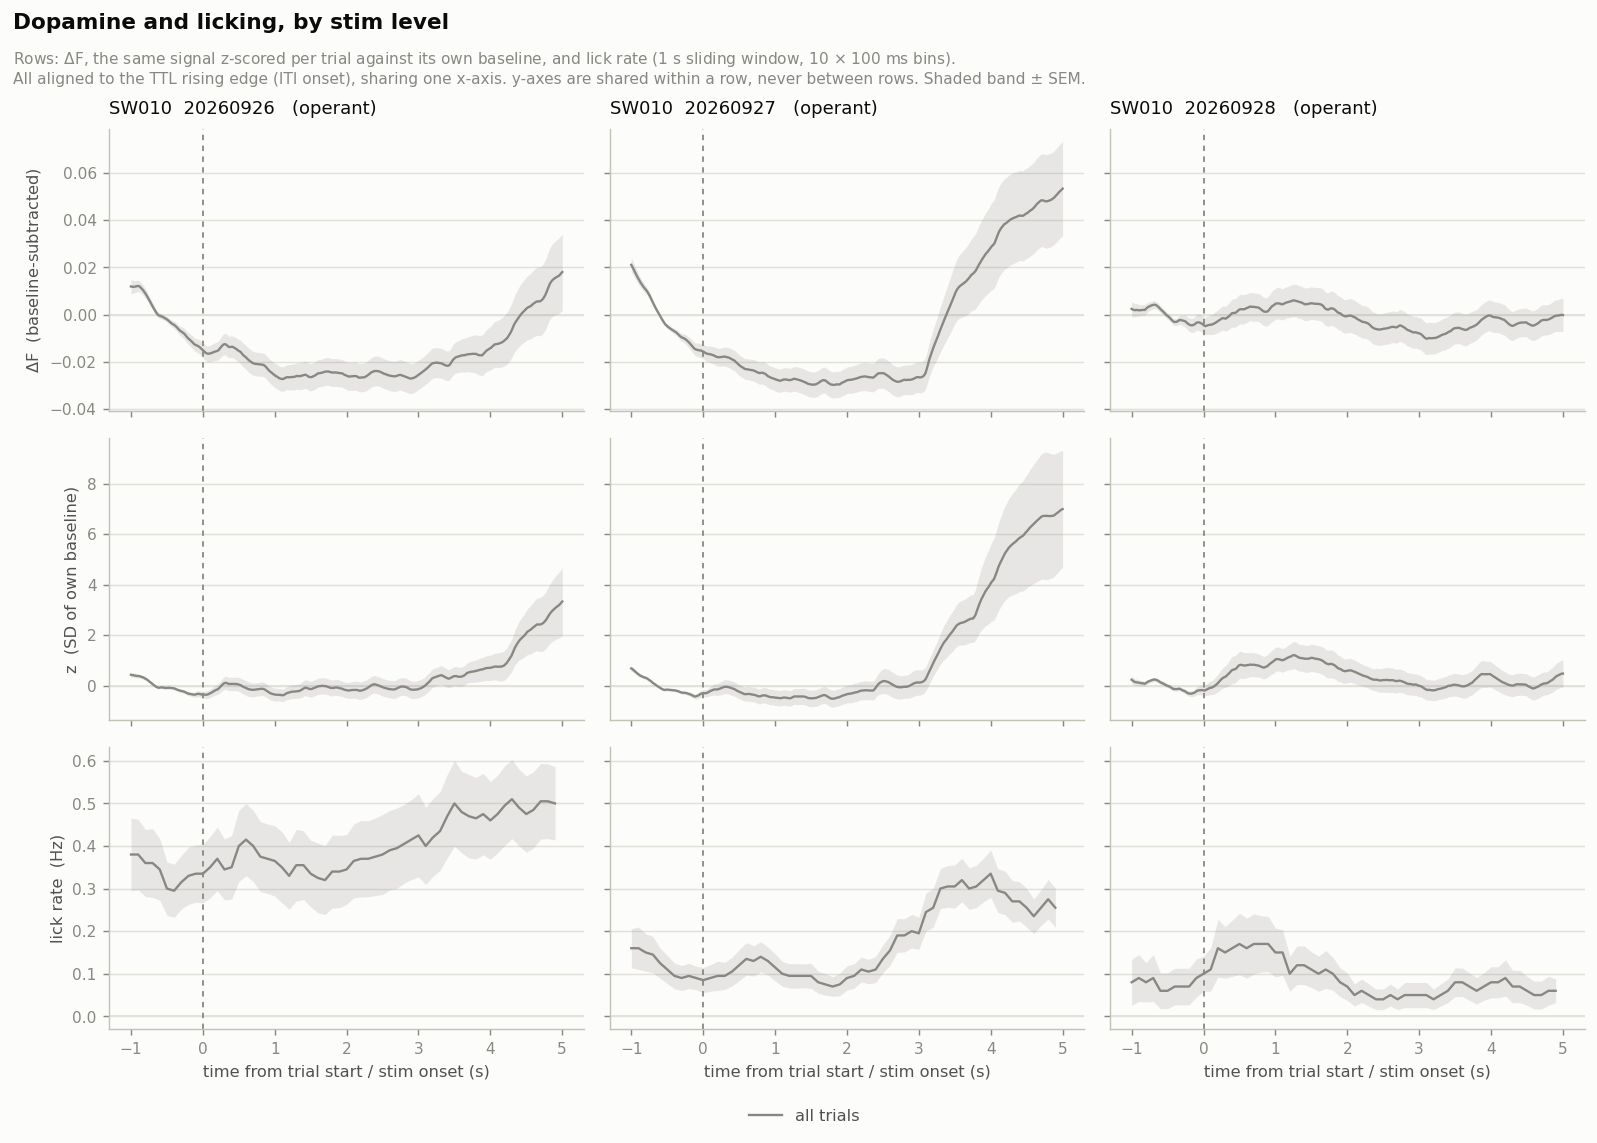

In [28]:
# One row per measure, all sharing the x-axis. Never a twin y-axis: the three
# are in different units, so a single scale would be meaningless. Middle row is
# the same dopamine signal as the top, in each animal's own noise units.
#
# Alignment is the TTL rising edge -- ITI onset, which is where the stim fires
# on a classical DA-stim day. An operant recording is drawn as one curve: its
# stim, if any, rides on the response and is in the operant section below.
# Splitting the trials by stim level is the one part that needs Bpod, so a
# recording without a behavior file still gets its dopamine rows, drawn as a
# single unlabelled curve, and says so where the lick row would be.
STIM_ROWS = (("$\\Delta$F  (baseline-subtracted)", "sub"),
             ("z  (SD of own baseline)", "z"),
             ("lick rate  (Hz)", "lick"))
STIM_XLABEL = "time from trial start / stim onset (s)"

fig, axes = session_grid(len(STIM_ROWS), names)
last_stim = stim_names[-1] if stim_names else None

for j, name in enumerate(names):
    photo, sess = recs[name]
    times = event_times_of(photo, sess, "trial_start")
    for r, (_, kind) in enumerate(STIM_ROWS):
        ax = axes[r, j]
        ax.set_facecolor(SURFACE)
        if kind == "lick" and sess is None:
            no_licks_panel(ax, STIM_XLABEL)
            continue
        curves = (lick_psth(sess, times) if kind == "lick"
                  else psth(photo, "trial_start", sess, norm=kind))
        draw_psth(ax, curves,
                  title=rec_title(name, sess) if r == 0 else "",
                  # the shared x-axis is labelled on the bottom row only
                  xlabel=STIM_XLABEL if r == len(STIM_ROWS) - 1 else "",
                  label_peaks=(r == 0 and name == last_stim),
                  stim_known=stim_at_start(sess))

for r, (ylabel, _) in enumerate(STIM_ROWS):
    axes[r, 0].set_ylabel(ylabel, color=INK_2, fontsize=9)
figure_legend(fig, axes[0])

# Reserve the top and bottom strips first, then place the titles into the
# reserved space -- otherwise tight_layout lays out over them.
fig.tight_layout(rect=(0, 0.03, 1, 0.93))
fig.text(0.005, 0.99, "Dopamine and licking, by stim level",
         ha="left", va="top", color=INK, fontsize=12, fontweight="bold")
fig.text(0.005, 0.957, "Rows: $\\Delta$F, the same signal z-scored per trial against "
         "its own baseline, and lick rate (1 s sliding window, 10 × 100 ms bins).\n"
         "All aligned to the TTL rising edge (ITI onset), sharing one x-axis. y-axes are "
         "shared within a row, never between rows. Shaded band ± SEM.",
         ha="left", va="top", color=MUTED, fontsize=8.5)
plt.show()


In [29]:
# The read above in numbers: baseline vs post-stim lick rate, per condition.
rows = []
for name in stim_names:
    photo, sess = recs[name]
    times = event_times_of(photo, sess, "trial_start")
    for v, (t, mu, sem, n) in lick_psth(sess, times).items():
        pre, post = mu[t < -0.1], mu[(t >= 0) & (t <= 2)]
        rows.append({"session": name, "stim": v, "n": n,
                     "pre (Hz)": round(float(pre.mean()), 2),
                     "0-2 s (Hz)": round(float(post.mean()), 2),
                     "delta (Hz)": round(float(post.mean() - pre.mean()), 2)})

lick_rates = pd.DataFrame(rows)
if rows:
    display(lick_rates.pivot(index="session", columns="stim", values="delta (Hz)"))
else:
    print("no recording here has stim levels -- that split needs a behavior file.")


no recording here has stim levels -- that split needs a behavior file.


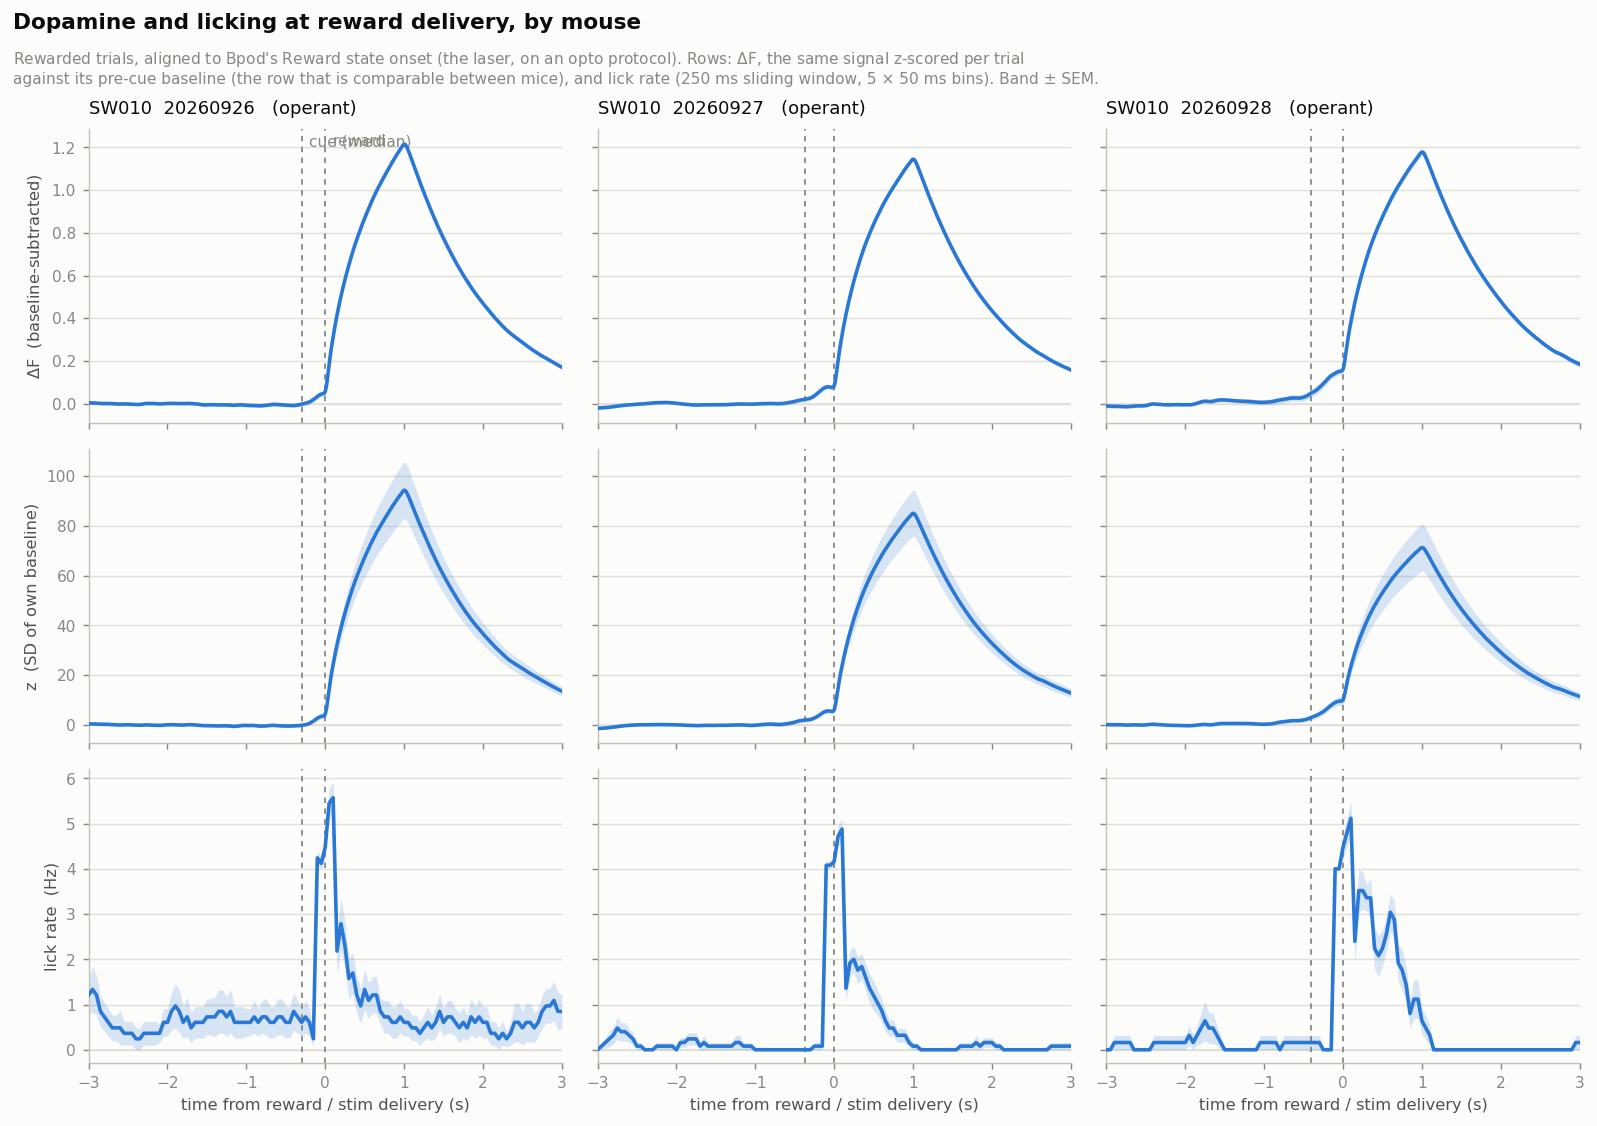

,recording,behavior,operant,trials,cue->reward (s),peak dF,sem,peak latency (s),dip dF,peak z,lick pre (Hz),lick peak (Hz),lick peak (s)
0,SW010_20260926,True,True,33,0.292,1.2148,0.0105,1.006,0.0575,94.3,0.65,5.58,0.1
1,SW010_20260927,True,True,50,0.371,1.1448,0.0095,1.002,0.0835,85.0,0.11,4.88,0.1
2,SW010_20260928,True,True,25,0.407,1.1778,0.0151,1.002,0.1615,71.2,0.14,5.12,0.1


In [30]:
# ---- reward-aligned dopamine and licking ------------------------------------
# Reward time is Bpod's Reward state onset on each trial's own sync edge -- on a
# classical session that is the TTL fall + TTL_TRACE to ~1 ms, on an operant
# one it follows the lick. Only trials that entered Reward count, so an operant
# panel averages its rewarded trials alone. On an *opto* protocol the Reward
# state is what fires the laser, so "reward" there is stim delivery (SW010
# 20260926: a one-second ramp to 1.2 dF, ~25x its 0.046 water response).
# A recording with no behavior file falls back to TTL fall + TTL_TRACE.
REWARD_BASELINE = (-2.5, -1.6)   # 0.9 s, ending before cue onset on every trial
REWARD_COLOR = "#2a78d6"

# Finer than the stim figure's 1 s window: every trial is rewarded, so all of
# them count toward one curve, and consummatory licking rises within ~200 ms of
# reward. A 1 s window would smear that onset away.
REWARD_LICK_BIN, REWARD_LICK_WIN = 0.05, 5   # 250 ms window every 50 ms
REWARD_XLABEL = "time from reward / stim delivery (s)"

ROW_LABELS = ("$\\Delta$F  (baseline-subtracted)",
              "z  (SD of own baseline)",
              "lick rate  (Hz)")


def reward_tail(photo, rew):
    """Seconds from reward to the next trial start, worst case over trials.

    The widest tail still free of the next trial -- and so of the next stim,
    on a day that stimulated. It is 4.13 s on 20260905 but only 2.58 s on
    20260904, which is why this is measured per recording rather than fixed.
    """
    rises, rew = photo.sync_rises, rew[np.isfinite(rew)]
    j = np.searchsorted(rises, rew)
    gap = rises[j[j < rises.size]] - rew[j < rises.size]
    return float(gap.min()) if gap.size else np.inf


# Per recording: rewarded trials' reward times, and how long before each the cue
# came on -- fixed on a classical session, set by the lick on an operant one.
rewards, cue_lag = {}, {}
for name, (photo, sess) in recs.items():
    rew, cue = event_times_of(photo, sess, "reward"), event_times_of(photo, sess, "cue")
    ok = np.isfinite(rew)
    rewards[name], cue_lag[name] = rew[ok], (rew - cue)[ok]

# The baseline has to end before the earliest cue, or a cue response leaks in.
_lag = max((float(np.nanmax(v)) for v in cue_lag.values() if v.size), default=0.0)
if REWARD_BASELINE[1] > -_lag:
    print(f"!! REWARD_BASELINE ends at {REWARD_BASELINE[1]} s but a cue starts "
          f"{_lag:.2f} s before reward -- move it earlier")

# One window for the whole figure, so the panels stay comparable: the shortest
# safe tail across the recordings shown, rounded down to 0.1 s.
REWARD_WINDOW = (-3.0, min(4.0, float(np.floor(
    min(reward_tail(recs[n][0], rewards[n]) for n in names) * 10) / 10)))

fig, axes = session_grid(len(ROW_LABELS), names)

rows = []
for j, name in enumerate(names):
    photo, sess = recs[name]
    rew = rewards[name]
    cue_at = -float(np.nanmedian(cue_lag[name])) if rew.size else np.nan
    t, M = pdm.epoch_signal(photo, rew, REWARD_WINDOW, which="F")
    # (time base, mean, sem) per row -- dopamine twice in different units, then
    # behaviour. Never a twin y-axis: dF, z and Hz share no meaningful scale.
    series = [(t,) + pdm.mean_sem(pdm.baseline_subtract(M, t, REWARD_BASELINE)),
              (t,) + pdm.mean_sem(pdm.zscore_baseline(M, t, REWARD_BASELINE))]
    if sess is not None:
        tl, R = lick_rate(sess, rew, REWARD_WINDOW, REWARD_LICK_BIN, REWARD_LICK_WIN)
        series.append((tl,) + pdm.mean_sem(R))

    for r in range(len(ROW_LABELS)):
        ax = axes[r, j]
        ax.set_facecolor(SURFACE)
        if r >= len(series):
            no_licks_panel(ax, REWARD_XLABEL)
            continue
        tt, mu, sem = series[r]
        ax.fill_between(tt, mu - sem, mu + sem, color=REWARD_COLOR, alpha=0.18,
                        linewidth=0, zorder=2)
        # One series per panel, so the panel title carries identity -- no legend
        # needed, and colour is not being asked to tell the mice apart.
        ax.plot(tt, mu, color=REWARD_COLOR, linewidth=2.0, zorder=4)

        # On an operant panel the cue mark is the median: each trial's cue sat
        # wherever that trial's lick put it.
        style_panel(ax, marks=(cue_at, 0),
                    title=rec_title(name, sess) if r == 0 else "",
                    xlabel=(REWARD_XLABEL if r == len(ROW_LABELS) - 1 else ""))
        ax.set_xlim(*REWARD_WINDOW)

    if not rew.size:
        rows.append({"recording": name, "behavior": sess is not None,
                     "operant": is_operant(sess), "trials": 0})
        continue
    (t_df, df, sem_df), (_, z, _) = series[0], series[1]
    w = (t_df >= 0) & (t_df <= 2)
    i = int(np.nanargmax(df[w]))
    # On a TTL-only recording "peak latency" doubles as the check on TTL_TRACE:
    # the transient sits ~0.2 s after water on the paired sessions, so a latency
    # far from that would mean this recording did not run a 1.5 s trace period.
    row = {"recording": name, "behavior": sess is not None,
           "operant": is_operant(sess),
           "trials": int(np.isfinite(M[:, 0]).sum()),
           "cue->reward (s)": round(float(np.nanmedian(cue_lag[name])), 3),
           "peak dF": round(float(df[w][i]), 4),
           "sem": round(float(sem_df[w][i]), 4),
           "peak latency (s)": round(float(t_df[w][i]), 3),
           "dip dF": round(float(np.nanmin(df[w])), 4),
           "peak z": round(float(np.nanmax(z[w])), 1)}
    if sess is not None:
        t_lk, lk = series[2][0], series[2][1]
        wl = (t_lk >= 0) & (t_lk <= 2)
        row |= {"lick pre (Hz)": round(float(np.nanmean(lk[t_lk < cue_at])), 2),
                "lick peak (Hz)": round(float(np.nanmax(lk[wl])), 2),
                "lick peak (s)": round(float(t_lk[wl][np.nanargmax(lk[wl])]), 2)}
    rows.append(row)

# Event labels once, in the first panel only -- repeating them in every panel
# would be nine times the ink for the same information. They go at the top of
# the dF row, the one corner no curve reaches.
hi = axes[0, 0].get_ylim()[1]
_cue0 = -float(np.nanmedian(cue_lag[names[0]])) if rewards[names[0]].size else np.nan
for x, lab in ((_cue0, "cue (median)" if is_operant(recs[names[0]][1]) else "cue"),
               (0, "reward")):
    if np.isfinite(x):
        axes[0, 0].annotate(lab, (x, hi), xytext=(4, -3), textcoords="offset points",
                            ha="left", va="top", color=MUTED, fontsize=8.5)

for r, ylabel in enumerate(ROW_LABELS):
    axes[r, 0].set_ylabel(ylabel, color=INK_2, fontsize=9)

fig.tight_layout(rect=(0, 0, 1, 0.93))
fig.text(0.005, 0.99, "Dopamine and licking at reward delivery, by mouse",
         ha="left", va="top", color=INK, fontsize=12, fontweight="bold")
fig.text(0.005, 0.957, "Rewarded trials, aligned to Bpod's Reward state onset (the laser, "
         "on an opto protocol). Rows: $\\Delta$F, the same signal z-scored per trial\n"
         "against its pre-cue baseline (the row that is comparable between mice), and "
         "lick rate (250 ms sliding window, 5 \u00d7 50 ms bins). Band \u00b1 SEM.",
         ha="left", va="top", color=MUTED, fontsize=8.5)
plt.show()

reward_peaks = pd.DataFrame(rows)
reward_peaks


## Stim vs reward, side by side

Classical sessions only: the stim here is the one fired at trial start. On an operant
session the laser rides on the response instead -- see the operant section below.

Sections 3 and 5 each share y *across* mice, which answers "who responds more?".
This one shares y **within** a mouse, across the two events — the question that
setup cannot answer: for this animal, how big is the stim transient next to the
one reward already produces?

$\Delta$F only, and dopamine only. Putting z or a lick rate in the same row
would hand the two panels different scales again, which is exactly what the
shared axis is here to avoid.


In [31]:
# Stim and reward side by side, one row per recording, **y shared across the
# pair**. That shared axis is the point: everywhere else in this notebook y is
# shared within a row *across* mice, which answers "who responds more?". Here it
# is shared within a mouse *across* events, which answers the other question --
# for this animal, how does the stim transient compare with the one reward
# already produces? $\Delta$F only, and dopamine only: two normalisations, or a
# lick row, would put the two panels back on two different scales.
#
# x is deliberately *not* shared -- the columns are different events with
# different windows.
# Classical recordings only -- on an operant one the stim is not at trial start.
pair_names = [n for n in names if not is_operant(recs[n][1])]
if not pair_names:
    print("every selected recording is operant -- see the operant section below.")
else:

    PAIR_H, PAIR_HEADER, PAIR_FOOT = 2.5, 0.85, 0.45   # inches: row, title strip, legend

    fig, axes = plt.subplots(len(pair_names), 2, squeeze=False, sharey="row",
                             figsize=(8.6, PAIR_H * len(pair_names) + PAIR_HEADER + PAIR_FOOT),
                             dpi=130)
    fig.patch.set_facecolor(SURFACE)

    for r, name in enumerate(pair_names):
        photo, sess = recs[name]

        # Left: aligned to the TTL rising edge, split by stim level where Bpod says.
        draw_psth(axes[r, 0], psth(photo, "trial_start", sess),
                  title="stim  (trial start)" if r == 0 else "",
                  xlabel="time from trial start (s)" if r == len(pair_names) - 1 else "",
                  stim_known=stim_at_start(sess))
        axes[r, 0].set_xlim(*WINDOW)

        # Right: every trial is rewarded, so there is nothing to split by -- one
        # curve, in the reward figure's blue rather than a stim-ramp colour, so it
        # never reads as a fourth condition.
        t, M = pdm.epoch_signal(photo, rewards[name], REWARD_WINDOW, which="F")
        mu, sem = pdm.mean_sem(pdm.baseline_subtract(M, t, REWARD_BASELINE))
        ax = axes[r, 1]
        ax.fill_between(t, mu - sem, mu + sem, color=REWARD_COLOR, alpha=0.18,
                        linewidth=0, zorder=2)
        ax.plot(t, mu, color=REWARD_COLOR, linewidth=2.0, zorder=4)
        style_panel(ax, marks=(-TTL_TRACE, 0),
                    title="reward  (Bpod Reward state)" if r == 0 else "",
                    xlabel="time from reward (s)" if r == len(pair_names) - 1 else "")
        ax.set_xlim(*REWARD_WINDOW)

        axes[r, 0].set_ylabel(name.replace("_", "  ")
                              + ("\n(TTL only)" if sess is None else "")
                              + "\n$\\Delta$F", color=INK_2, fontsize=9, linespacing=1.6)

    figure_legend(fig, axes[:, 0])   # stim levels; the reward panel has one series

    # Strips reserved in inches, so the header keeps its size whatever the row count.
    h = fig.get_figheight()
    fig.tight_layout(rect=(0, PAIR_FOOT / h, 1, 1 - PAIR_HEADER / h))
    fig.text(0.005, 1 - 0.12 / h, "Stim vs reward on one scale, per mouse",
             ha="left", va="top", color=INK, fontsize=12, fontweight="bold")
    fig.text(0.005, 1 - 0.42 / h, "$\\Delta$F, baseline-subtracted. Each row shares one "
             "y-axis between its two panels, so that mouse's stim transient and its\nreward "
             "transient are directly comparable in size. Rows are not comparable with each "
             "other. Band ± SEM.",
             ha="left", va="top", color=MUTED, fontsize=8.5)
    plt.show()


every selected recording is operant -- see the operant section below.


## Operant sessions: cue and outcome

On an operant trial the cue runs until the first lick, or until the response
window closes, and Bpod then moves to `Reward` or `NoReward`. So there are two
moments to align on, each with its own split:

- **cue onset** (still the TTL falling edge), split by *which cue played* -- the
  animal cannot know the outcome yet;
- **outcome** (Bpod's `Reward_on` / `NoReward_on`), split by *what happened*:
  rewarded -- water, or the laser on an opto protocol -- licked but unrewarded,
  or no lick inside the window.

Outcome-aligned rows are baselined on each trial's **pre-cue** window, not the
second before the outcome: that second is mostly cue, and would subtract the cue
response out of everything after it.


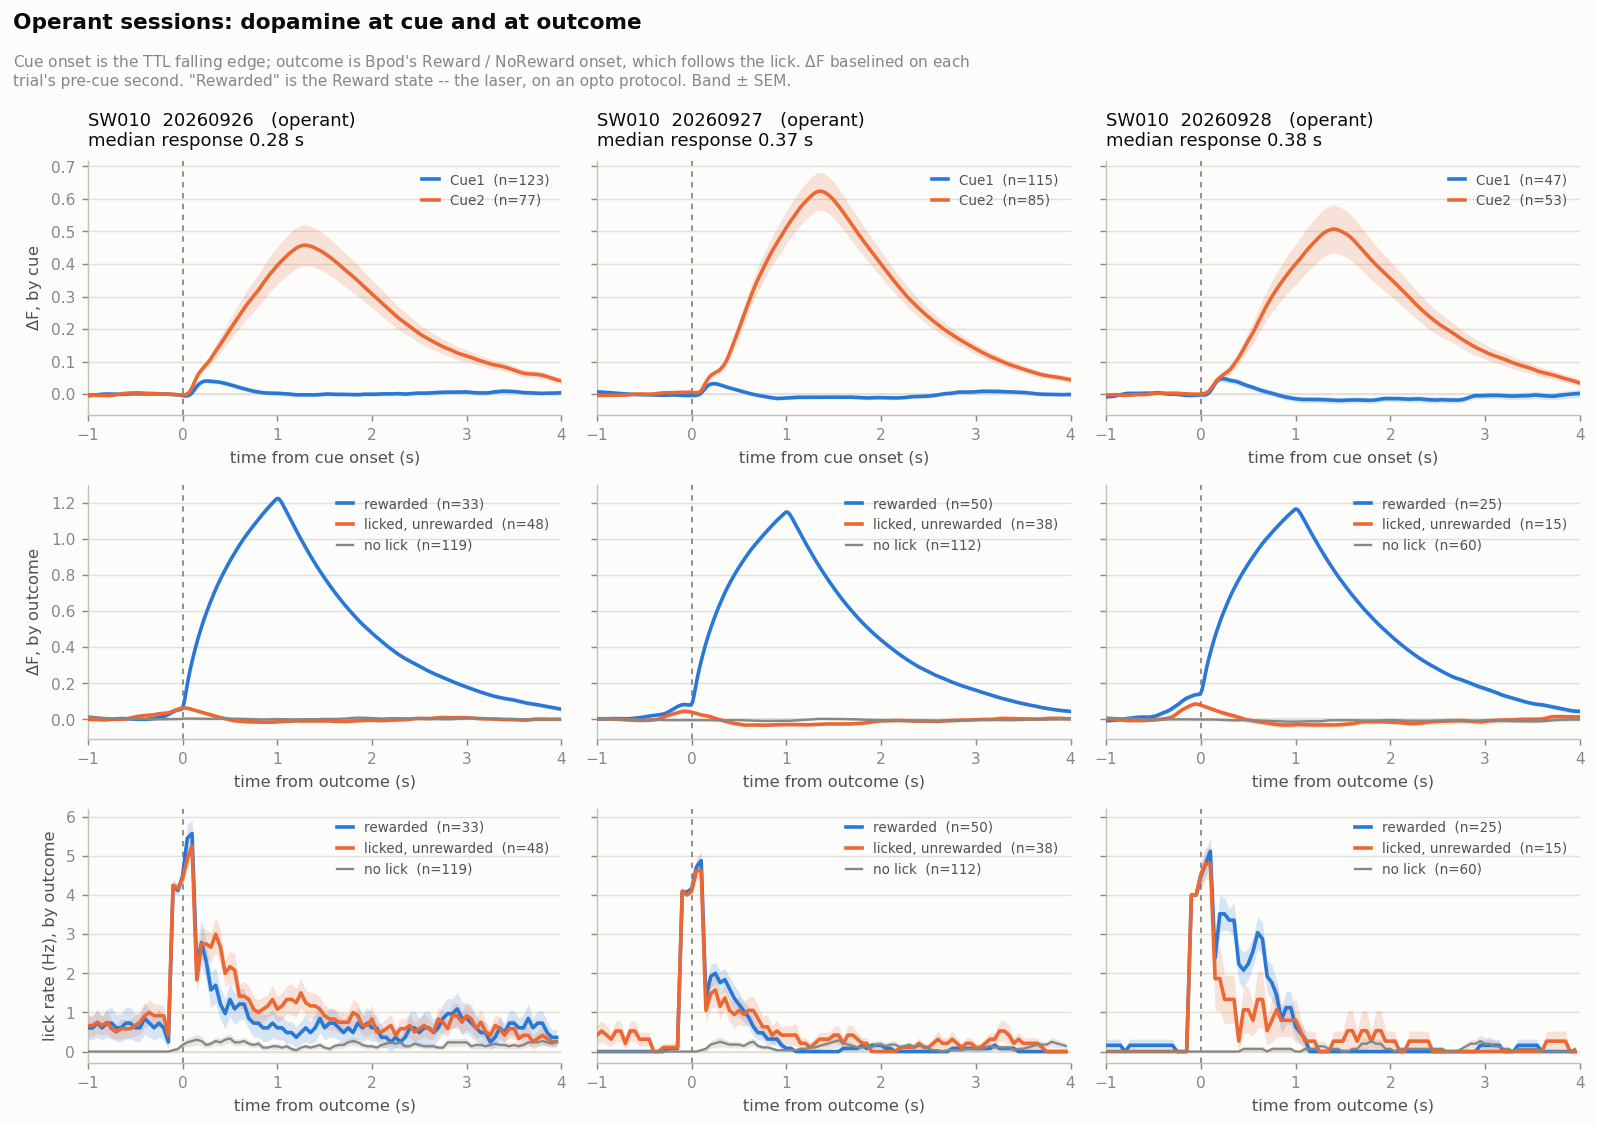

outcome,"licked, unrewarded",no lick,rewarded
recording,,,
SW010_20260926,0.0635,0.0052,1.2230
SW010_20260927,0.0403,0.0038,1.1481
SW010_20260928,0.0792,0.0003,1.1641


In [32]:
OP_WINDOW, OP_BASELINE = (-1.0, 4.0), (-1.0, -0.1)   # baseline is pre-cue
# Categorical slots 1 and 2, in fixed order. "No lick" is the absence of an
# outcome, so it takes the muted neutral rather than a third hue.
CUE_COLORS = ("#2a78d6", "#eb6834")
OUTCOMES = {"rewarded": "#2a78d6", "licked, unrewarded": "#eb6834", "no lick": MUTED}
OP_ROWS = (("$\\Delta$F, by cue", "time from cue onset (s)"),
           ("$\\Delta$F, by outcome", "time from outcome (s)"),
           ("lick rate (Hz), by outcome", "time from outcome (s)"))


def cue_labels(sess):
    """Per trial, the cue state it played ("Cue1", "Cue2", ...), "" if none."""
    df = sess.trials
    return np.select([df[f"{c}_entered"].to_numpy(bool) for c in sess.cue_states],
                     sess.cue_states, "")


def response_time(sess):
    """Seconds from cue onset to the cue ending -- the lick, or the window closing."""
    df = sess.trials
    return np.fmin.reduce(np.column_stack(
        [(df[f"{c}_off"] - df[f"{c}_on"]).to_numpy(float) for c in sess.cue_states]), axis=1)


def outcome_labels(sess, atol=0.005):
    """Per trial: "rewarded", "licked, unrewarded", "no lick", or "" (no cue).

    "No lick" is a cue that ran the full response window -- the longest cue in
    the session -- instead of being cut short by a lick.
    """
    df = sess.trials
    rt = response_time(sess)
    rewarded = (df["Reward_entered"].to_numpy(bool) if "Reward_entered" in df
                else np.zeros(len(df), bool))
    miss = np.isclose(rt, np.nanmax(rt), atol=atol)
    out = np.where(rewarded, "rewarded",
                   np.where(miss, "no lick", "licked, unrewarded"))
    return np.where(np.isfinite(rt) | rewarded, out, "")


def split_labels(t, M, labels, order):
    """{label: (t, mean, sem, n)} for each label in ``order`` that has trials."""
    out = {}
    for lab in order:
        rows = M[(labels == lab) & np.isfinite(M).any(axis=1)]
        if rows.shape[0]:
            out[lab] = (t,) + pdm.mean_sem(rows) + (rows.shape[0],)
    return out


def draw_groups(ax, curves, colors):
    for lab, (t, mu, sem, n) in curves.items():
        c = colors[lab]
        ax.fill_between(t, mu - sem, mu + sem, color=c, alpha=0.18, linewidth=0, zorder=2)
        ax.plot(t, mu, color=c, linewidth=2.0 if c != MUTED else 1.3, zorder=4,
                label=f"{lab}  (n={n})")
    # n differs per recording, so each panel keeps its own small legend.
    ax.legend(frameon=False, fontsize=7.5, loc="upper right", labelcolor=INK_2,
              handlelength=1.2)


if not operant_names:
    print("no operant recording selected.")
else:
    fig, axes = plt.subplots(len(OP_ROWS), len(operant_names), squeeze=False,
                             sharey="row", dpi=130,
                             figsize=(4.1 * len(operant_names), 2.9 * len(OP_ROWS)))
    fig.patch.set_facecolor(SURFACE)

    rows = []
    for j, name in enumerate(operant_names):
        photo, sess = recs[name]
        cue_t = event_times_of(photo, sess, "cue")
        out_t = event_times_of(photo, sess, "outcome")
        cues, outs, rt = cue_labels(sess), outcome_labels(sess), response_time(sess)

        tc, Mc = pdm.epoch_signal(photo, cue_t, OP_WINDOW, which="F")
        tb, Mb = pdm.epoch_signal(photo, cue_t, OP_BASELINE, which="F")
        base = np.nanmean(Mb, axis=1, keepdims=True)   # each trial's pre-cue level
        to, Mo = pdm.epoch_signal(photo, out_t, OP_WINDOW, which="F")
        tl, R = lick_rate(sess, out_t, OP_WINDOW, REWARD_LICK_BIN, REWARD_LICK_WIN)

        panels = (split_labels(tc, Mc - base, cues, sess.cue_states),
                  split_labels(to, Mo - base, outs, OUTCOMES),
                  split_labels(tl, R, outs, OUTCOMES))
        cue_colors = dict(zip(sess.cue_states, CUE_COLORS))
        for r, (curves, (_, xlabel)) in enumerate(zip(panels, OP_ROWS)):
            ax = axes[r, j]
            draw_groups(ax, curves, cue_colors if r == 0 else OUTCOMES)
            style_panel(ax, xlabel=xlabel,
                        title=(f"{rec_title(name, sess)}"
                               f"\nmedian response {np.nanmedian(rt[outs != 'no lick']):.2f} s"
                               if r == 0 else ""))
            ax.set_xlim(*OP_WINDOW)

        w = (to >= 0) & (to <= 1.5)
        for lab, (_, mu, sem, n) in panels[1].items():
            k = int(np.nanargmax(mu[w]))
            rows.append({"recording": name, "outcome": lab, "n": n,
                         "peak dF (0-1.5 s)": round(float(mu[w][k]), 4),
                         "sem": round(float(sem[w][k]), 4),
                         "peak latency (s)": round(float(to[w][k]), 3)})

    for r, (ylabel, _) in enumerate(OP_ROWS):
        axes[r, 0].set_ylabel(ylabel, color=INK_2, fontsize=9)

    fig.tight_layout(rect=(0, 0, 1, 0.92))
    fig.text(0.005, 0.99, "Operant sessions: dopamine at cue and at outcome",
             ha="left", va="top", color=INK, fontsize=12, fontweight="bold")
    fig.text(0.005, 0.955, "Cue onset is the TTL falling edge; outcome is Bpod's Reward / "
             "NoReward onset, which follows the lick. $\\Delta$F baselined on each\n"
             "trial's pre-cue second. \"Rewarded\" is the Reward state -- the laser, on an "
             "opto protocol. Band \u00b1 SEM.",
             ha="left", va="top", color=MUTED, fontsize=8.5)
    plt.show()

    operant_peaks = pd.DataFrame(rows)
    display(operant_peaks.pivot(index="recording", columns="outcome",
                                values="peak dF (0-1.5 s)"))



| | SW007 | SW008 | SW010 |
|---|---|---|---|
| whole-trace SD | 0.0066 | 0.0511 | 0.0497 |
| peak $\Delta$F | 0.034 | 0.183 | 0.046 |
| **peak in own SD** | **11.3** | 8.5 | **3.9** |
| single trials clearing 2 SD | 99% | 97% | 73% |
| latency SD | 30 ms | 59 ms | 187 ms |
| avg / mean single-trial peak | 0.97 | 0.94 | 0.78 |